### Two-dimensional Poisson Equation

$$
-\nabla^2u(x,y)=f(x,y)
$$

where

$$
\nabla^2u
=
\frac{\partial^2u}{\partial x^2}
+
\frac{\partial^2u}{\partial y^2}
$$

We solve the following Poisson equation using a Physics-Informed Neural Network:

$$
-\left(
\frac{\partial^2u}{\partial x^2}
+
\frac{\partial^2u}{\partial y^2}
\right)
=
(\pi^2-1)e^x\sin(\pi y)
$$

Domain :

$$
x,y\in[0,1]
$$

Boundary Conditions :

$$
u(0,y)=\sin(\pi y)
$$

$$
u(1,y)=e\,\sin(\pi y)
$$

$$
u(x,0)=0
$$

$$
u(x,1)=0
$$

### Analytical Solution

The exact solution is

$$
u(x,y)=e^x\sin(\pi y).
$$

In [38]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

In [39]:
# domain
N_x, N_y = 101, 101
x = torch.linspace(0.0,1.0,N_x,requires_grad=True)
y = torch.linspace(0.0,1.0,N_y,requires_grad=True)

x_mesh, y_mesh = torch.meshgrid(x,y)
input = torch.column_stack((x_mesh.flatten(), y_mesh.flatten()))
print(input.shape)

torch.Size([10201, 2])


In [40]:
# defining the source function
def f(input):
    input_x = input[:,0]
    input_y = input[:,1]
    return (torch.pi**2 - 1) * torch.exp(input_x) * torch.sin(torch.pi * input_y)

In [41]:
# model
model = nn.Sequential(
    nn.Linear(2,20),
    nn.Tanh(),
    nn.Linear(20,20),
    nn.Tanh(),
    nn.Linear(20,1)
)

In [42]:
# loss function
def Loss(model,x,y,x_mesh,y_mesh,input):
    u = model(input).reshape(N_x,N_y)
    
    # gradients
    # x gradients
    dudx = torch.autograd.grad(
        outputs = u,
        inputs = x_mesh,
        grad_outputs=torch.ones_like(u),
        create_graph=True
    )[0]

    d2udx2 = torch.autograd.grad(
        outputs = dudx,
        inputs = x_mesh,
        grad_outputs=torch.ones_like(dudx),
        create_graph=True
    )[0]

    # y gradients
    dudy = torch.autograd.grad(
        outputs = u,
        inputs = y_mesh,
        grad_outputs=torch.ones_like(u),
        create_graph=True
    )[0]

    d2udy2 = torch.autograd.grad(
        outputs = dudy,
        inputs = y_mesh,
        grad_outputs=torch.ones_like(dudy),
        create_graph=True
    )[0]

    # ode loss
    loss_ode = torch.mean((d2udx2 + d2udy2 + f(input).reshape(N_x,N_y))**2)

    # bc loss
    loss_bc = torch.mean(u[:,0]**2 + u[:,-1]**2 + (u[0,:] - torch.sin(torch.pi * y))**2 + (u[-1,:] - torch.exp(torch.tensor(1.0))*torch.sin(torch.pi * y))**2)

    return loss_ode + loss_bc

In [43]:
# optimizers
optim_adam = torch.optim.Adam(model.parameters(), lr = 0.001)
optim_lbfgs = torch.optim.LBFGS(model.parameters(), lr = 1.0, max_iter=5000, max_eval=5000, tolerance_grad=10**-9, tolerance_change=10**-11, line_search_fn="strong_wolfe")

In [44]:
# training the PINN using Adam optimizer
N_epoch_adam = 10000
loss_arr_adam = []
print("Training using Adam Optimizer started")
for epoch in range(N_epoch_adam):
    loss = Loss(model, x, y, x_mesh, y_mesh, input)
    loss_arr_adam.append(loss.item())
    loss.backward()
    optim_adam.step()
    optim_adam.zero_grad()
print("Training using Adam Optimizer finished")

Training using Adam Optimizer started
Training using Adam Optimizer finished


In [45]:
# training the PINN using lbfgs optimizer after the Adam optimizer
loss_arr_lbfgs = []

def closure():
    optim_lbfgs.zero_grad()
    loss = Loss(model, x, y, x_mesh, y_mesh, input)
    loss_arr_lbfgs.append(loss.item())
    loss.backward()
    return loss

print("Training using LBFGS Optimizer started")
optim_lbfgs.step(closure)
print("Training using LBFGS Optimizer finished")

Training using LBFGS Optimizer started
Training using LBFGS Optimizer finished


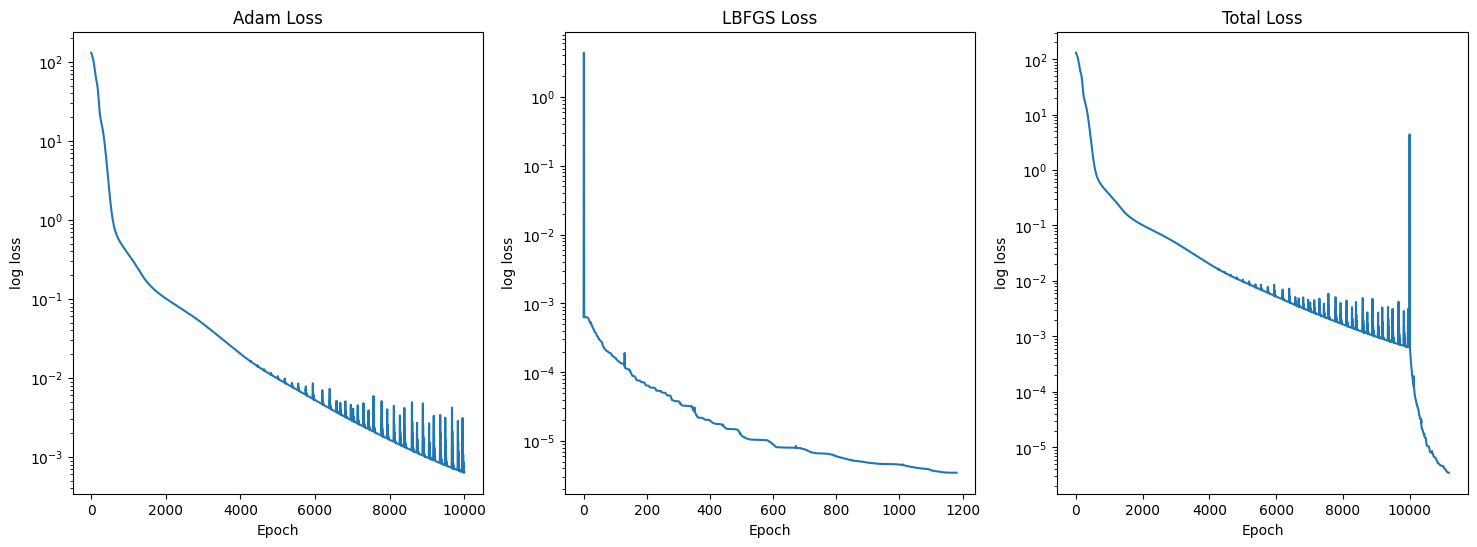

In [46]:
# loss visualisation
plt.figure(figsize = (18,6))

plt.subplot(1,3,1)
plt.semilogy(loss_arr_adam)
plt.title("Adam Loss")
plt.xlabel("Epoch")
plt.ylabel("log loss")

plt.subplot(1,3,2)
plt.semilogy(loss_arr_lbfgs)
plt.title("LBFGS Loss")
plt.xlabel("Epoch")
plt.ylabel("log loss")

plt.subplot(1,3,3)
plt.semilogy(loss_arr_adam + loss_arr_lbfgs)
plt.title("Total Loss")
plt.xlabel("Epoch")
plt.ylabel("log loss")
plt.show()

In [47]:
# exact function
with torch.no_grad():
    u_exact = torch.exp(x_mesh) * torch.sin(torch.pi * y_mesh)
    u_nn = model(input).reshape(N_x,N_y)

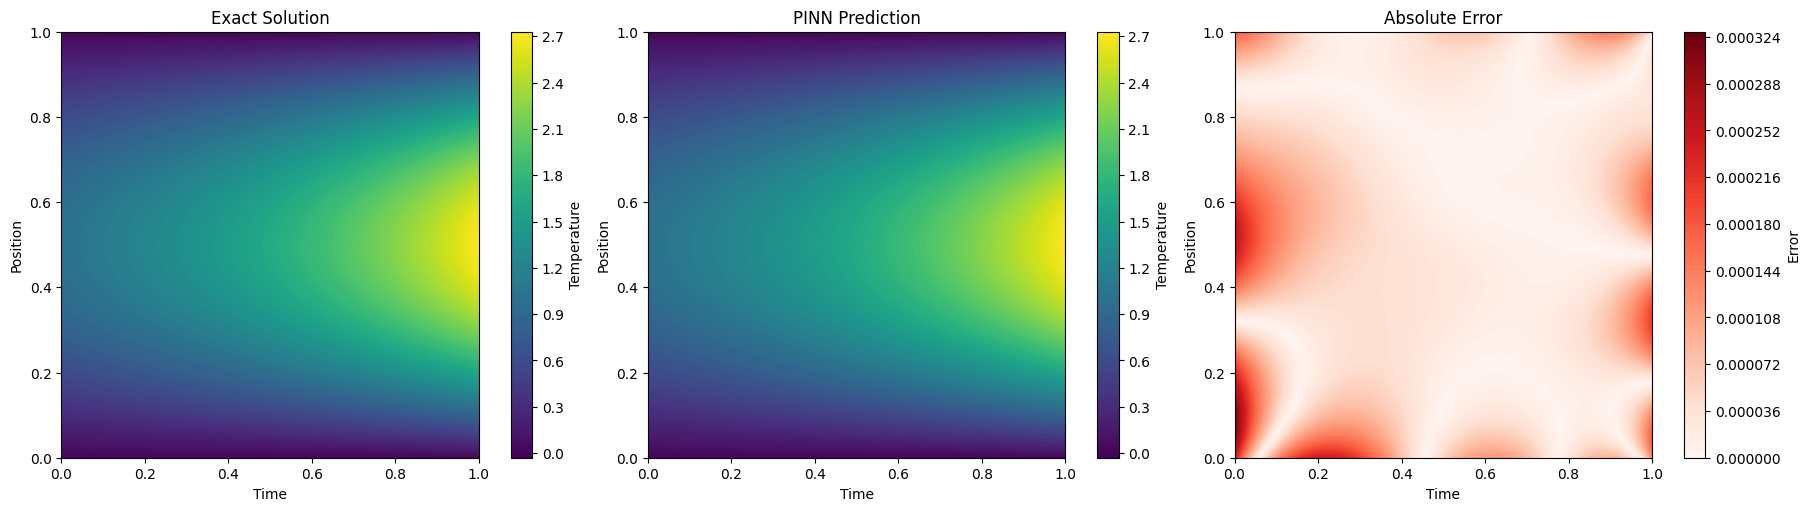

In [48]:
error = torch.abs(u_nn - u_exact)

fig, ax = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

# Exact solution
c1 = ax[0].contourf(
    x_mesh.detach(),
    y_mesh.detach(),
    u_exact.detach(),
    levels=100,
    cmap="viridis"
)
ax[0].set_title("Exact Solution")
ax[0].set_xlabel("Time")
ax[0].set_ylabel("Position")
fig.colorbar(c1, ax=ax[0], label="Temperature")

# PINN prediction
c2 = ax[1].contourf(
    x_mesh.detach(),
    y_mesh.detach(),
    u_nn.detach(),
    levels=100,
    cmap="viridis"
)
ax[1].set_title("PINN Prediction")
ax[1].set_xlabel("Time")
ax[1].set_ylabel("Position")
fig.colorbar(c2, ax=ax[1], label="Temperature")

# Absolute error
c3 = ax[2].contourf(
    x_mesh.detach(),
    y_mesh.detach(),
    error.detach(),
    levels=100,
    cmap="Reds"
)
ax[2].set_title("Absolute Error")
ax[2].set_xlabel("Time")
ax[2].set_ylabel("Position")
fig.colorbar(c3, ax=ax[2], label="Error")

plt.show()